# Nepali Sentiment Classification Using BERT

### Dataset Used for Fine-Tuning: [NepaliSentiment](https://huggingface.co/datasets/Shushant/NepaliSentiment)

### Model Used for Fine-Tuning: [nepaliBERT](https://huggingface.co/Shushant/nepaliBERT)

## 1. Import required libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
import torch
import mlflow
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from datasets import load_dataset
from huggingface_hub import HfApi
from huggingface_hub import notebook_login
from transformers.integrations import MLflowCallback
from optimum.onnxruntime import ORTModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import pipeline, Trainer, AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, DataCollatorWithPadding

## 2. Setup MLflow

In [3]:
# Define the MLflow tracking URI with SQLite
MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"

# Set MLflow tracking URI
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

In [4]:
# Set or create an experiment
mlflow.set_experiment("Nepali_Sentiment_Classification")

2025/11/19 15:59:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/19 15:59:29 INFO mlflow.store.db.utils: Updating database tables
2025-11-19 15:59:29 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-19 15:59:29 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-19 15:59:29 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-19 15:59:29 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


<Experiment: artifact_location='/home/aashish/Amnil-AI-Internship/mlruns/1', creation_time=1763534127298, experiment_id='1', last_update_time=1763534127298, lifecycle_stage='active', name='Nepali_Sentiment_Classification', tags={'mlflow.experimentKind': 'custom_model_development'}>

## 3. Load Nepali Sentiment Dataset

In [5]:
nepali_sentiment = load_dataset("Shushant/NepaliSentiment")

In [6]:
nepali_sentiment

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1996
    })
})

In [7]:
nepali_sentiment['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 6000
})

In [8]:
nepali_sentiment['test']

Dataset({
    features: ['text', 'label'],
    num_rows: 1996
})

In [9]:
nepali_sentiment['train'][0]

{'text': 'बजार ले जसरी ट्रेन्ड चेन्ज गर्यो यो हेर्दा तत्काल प्रोफिट बूकिङ आउने सम्भावना रहेन ! भोलि अर्को ट्रेन्ड समात्न सक्ने अबस्था पनि दरो छ',
 'label': '2'}

In [10]:
nepali_sentiment['test'][:3]

{'text': ['असाध्यै राम्रो कार्यक्रम आयोजना गरिएको छ हजुरहरुको यो महान् कामले महान्ता झल्किएको छ महानायक त्यो हो जस्ले समाज को लागी महान काम गर्ने छ त्यो एकमात्र हिरो राजेश हमाल जय नेपाल।',
  'राम्रो कार्यक्रम, पहिलो सिजनले समेटेको कार्यक्रम पुरै हेरेँ र यो सिजनको हेर्न सुरु गरेको छु, यसले सार्थकता पाउँछ भन्नेमा आशावादी छु, केही अन्तरजातीय बिबाह वा उच्च समुदाय भनेर चिनिएको समुदायका केही परिवारको सफल भएका उदाहरणहरू र त्यहाँ के कस्ता सही र गलत भएका छन् भन्ने कुरालाई नि समेट्न पाएँ राम्रो हुने थियो की जस्तो लाग्छ । धन्यवाद !!!',
  'महानायक राजेश हमाल तपाई साँच्चै धन्यवादको पात्र हुनुहुन्छ। यो कार्यक्रम लाई मन नपराउनेहरुको कमि छैन यँहा तर जातिय उत्पिडनमा परेकाहरूलाई यो कार्यक्रमले केही हद् सम्म न्याय पाउने आशा जगाउने छ। जय होस्। You are really Great sir'],
 'label': ['1', '1', '1']}

## 4. Overview of Nepali Sentiment Dataset

In [11]:
nepali_sentiment.set_format('pandas')
df_train = nepali_sentiment['train'][:]
df_test = nepali_sentiment['test'][:]
df_train.sample(frac=1 , random_state=1).head(10)

,text,label
1483,हेम थापा जि तपाई लाई गाली गर्न त मन छैन तरपनी ...,0
2185,यो देश लाई मिलाइ मिलाइ भाग लाई लाई सके,0
2520,यस्तो👆 स्टिङ हान्नु परो के दाजु!,0
3721,रबि लामिछाने को बिरोध गर्ने हरुले पिलिज यो कार...,2
3727,रबि जि जनतासग सिदा कुरा सुन्न पाउँदा मनै देखि ...,1
4524,"अब प्रधानमन्त्री रबि लामिछाने भए मात्रै देश बन्छ,",1
234,यस्ता भ्रष्टहरुलाई रोजेर पठाउने हामी जनता कस्त...,0
4735,सलुट रबि सर,1
5839,अत्यन्तै आनन्दायक र प्रसन्सायोग्य श्र्बयदृश्य...,1
2939,गाऊमा मात्रकिन छर्के हुन्छ काठमाडौं मा किन हुद...,0


In [12]:
df_train.loc[0, 'text']

'बजार ले जसरी ट्रेन्ड चेन्ज गर्यो यो हेर्दा तत्काल प्रोफिट बूकिङ आउने सम्भावना रहेन ! भोलि अर्को ट्रेन्ड समात्न सक्ने अबस्था पनि दरो छ'

In [13]:
df_train.label.value_counts()

label
1     2378
0     2377
2     1236
-        5
20       1
11       1
o        1
--       1
Name: count, dtype: int64

In [14]:
df_train[df_train['label'] == '-']

,text,label
4344,कुरा सुन्दा हासो र अनुहार हेर्दा मुटु त धुक ध...,-
4462,आझै हरेक न्याय नपायक जन्ता न्याय दिन सफल होस ...,-
4741,बैदेशिक रोजगारीमा जाने दाजुभाइ दिदिबहिनीहरु सब...,-
5309,जातिय बिभेद गर्नु पर्छ?,-
5437,रबि सर 🇳🇵७:३५ मिनेट का लागि मात्रै अरुको लागि ...,-


In [15]:
df_train[df_train['label'] == '20']

,text,label
850,उहाँ बाट नेपाल सप्रिने भन्दा बिग्रेर जान्छ।,20


In [16]:
df_train[df_train['label'] == '11']

,text,label
3883,लाखौं लाख सफलता को सुभकामना रबि सर,11


In [17]:
df_train[df_train['label'] == 'o']

,text,label
5251,रबि दाजु नमस्कार हजुरकाे हरेक कार्यक्रम नछुटाई...,o


In [18]:
df_train[df_train['label'] == '--']

,text,label
5654,"साँचो अर्थमा अमेरिका एक आफैमा बिस्व हो, संसार ...",--


In [19]:
# 0 is negative
df_train[df_train['label'] == '0']

,text,label
18,"भारत-मधेस र नेपाल-चीन सम्बन्ध विग्रन्छ, मधेसी ...",0
25,"लेखनाथ न्यौपानेको खुलासा,महाधिबेशनमा एमसीसीको ...",0
28,जे गरेपनि एमसीसीले संकट निम्ताउने देखियो' | Ge...,0
34,यो भ्रस्टाचारि लाई किन येति घमण्ड ?? ७० करोड क...,0
36,👉️ ७० करोडको अझै कति धेरै चुरिफुरी छ थुक्क हाम...,0
...,...,...
5985,बाहुनवादी सोँच सस्कार र बाहुनवादी राज्य संरचना...,0
5988,मलाई मनमा लागेको बाहुन साथि हरु लाई यो कार्यक्...,0
5990,हेला गर्नु हुन्न भन्ने जम्मा यतिका मान्छे मा ज...,0
5991,जात व्यवस्था हिन्दुवाद र ब्राह्मणवादको पराकाष्...,0


In [20]:
# 1 is neutral
df_train[df_train['label'] == '1']

,text,label
1,1000 अंकले घटेको नेप्से 200 अंकले बढ्नु ठूलो क...,1
4,राम्रो भयो️️,1
6,जानकारीको लागि धन्यवाद रामहरी ब्रदर,1
38,जसले जे सुकै भनेपनि गोकुल बास्कोटा काभ्रेको ब...,1
44,गोकुलजीले भनिसके त - भ्रस्टाचार गरेको रहेछ भने...,1
...,...,...
5993,"जुन सोछ, बिचार लाई आत्मा साथ गरेर अगाडि बढिरहन...",1
5994,"समाजको ऐना र यथार्थ , यहाहरुको प्रयासलाई सदैव ...",1
5995,समाज परिवर्तन गराउन लाई अरु को मुख हेर्ने भन्द...,1
5998,बधाई र सुभकामना ।।,1


In [21]:
# 2 is positive
df_train[df_train['label'] == '2']

,text,label
0,बजार ले जसरी ट्रेन्ड चेन्ज गर्यो यो हेर्दा तत्...,2
2,होइन यो सानिमा बैंक ले bonus घोसणा गरेको २ महि...,2
3,"खैँ MBJC प्रति कित्तामा रू,10/-ले बढेर आज रू,1...",2
5,"मध्यभोटेकोशिको शेयर ,, कर्मचारी संञ्चयकोष का स...",2
7,हाईड्रो र फाइनान्स बुम बुम भन्न छोडिएछ त ?,2
...,...,...
5947,नेपालका लागी नेपाली,2
5984,"जबसम्म थर थाहाहुँदैन तबसम्म विभेद हुँदैन, थर थ...",2
5986,यो सिजन मा एस कुमार दाइ लाई पनि समाबेस गरेको भ...,2
5996,"Filmy क्षेत्रमा धेरै गर्नु भयो,,अब समाज र देश ...",2


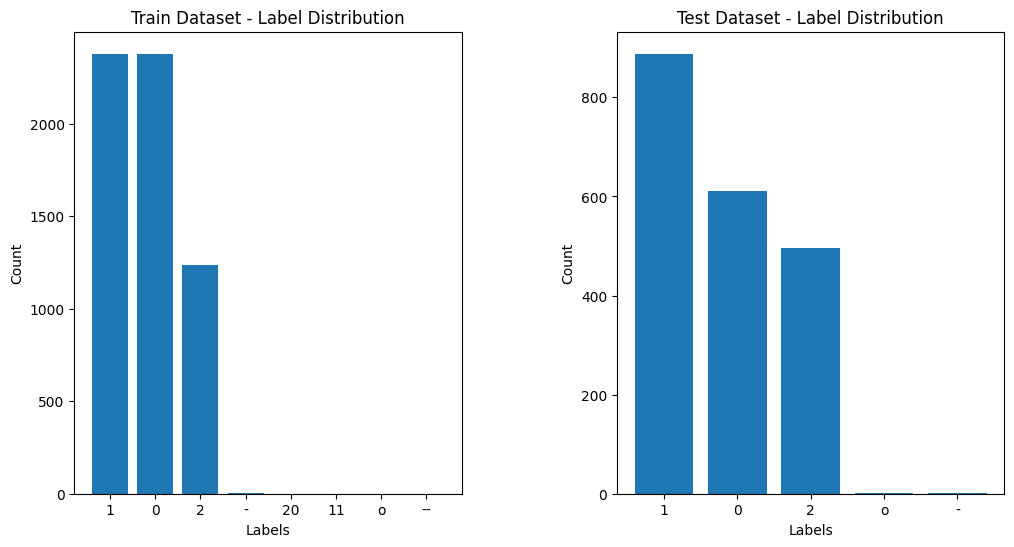

In [22]:
# Bar graph for train dataset
train_labels = df_train['label'].value_counts()

# Bar graph for test dataset
test_labels = df_test['label'].value_counts()

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Train dataset subplot
axs[0].bar(train_labels.index, train_labels.values)
axs[0].set_xlabel('Labels')
axs[0].set_ylabel('Count')
axs[0].set_title('Train Dataset - Label Distribution')

# Test dataset subplot
axs[1].bar(test_labels.index, test_labels.values)
axs[1].set_xlabel('Labels')
axs[1].set_ylabel('Count')
axs[1].set_title('Test Dataset - Label Distribution')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.4)

# Display the plot
plt.show()

In [23]:
# Check for missing values in the train dataset
train_na = df_train.isna().sum()
print('Train Dataset - Missing Values:')
print(train_na)

test_na = df_test.isna().sum()
print('\nTest Dataset - Missing Values:')
print(test_na)

print("Train Dataset Size:",df_train.shape )
print("Test Dataset Size:", df_test.shape)

Train Dataset - Missing Values:
text     1
label    0
dtype: int64

Test Dataset - Missing Values:
text     1
label    0
dtype: int64
Train Dataset Size: (6000, 2)
Test Dataset Size: (1996, 2)


In [24]:
nepali_sentiment.reset_format()

## 5. Data Preprocessing

In [25]:
# Training set labels before
print(Counter(nepali_sentiment['train']['label']))

Counter({'1': 2378, '0': 2377, '2': 1236, '-': 5, '20': 1, '11': 1, 'o': 1, '--': 1})


In [26]:
# Test set labels before
print(Counter(nepali_sentiment['test']['label']))

Counter({'1': 888, '0': 610, '2': 496, 'o': 1, '-': 1})


In [27]:
# Filter the dataset
nepali_sentiment = nepali_sentiment.filter(lambda example: example['label'] in ['0', '1', '2'])

In [28]:
nepali_sentiment

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 5991
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1994
    })
})

In [29]:
# Convert labels to integers
nepali_sentiment = nepali_sentiment.map(lambda example: {'label': int(example['label'])})

In [30]:
# Training set labels after
print(Counter(nepali_sentiment['train']['label']))

Counter({1: 2378, 0: 2377, 2: 1236})


In [31]:
# Test set labels after
print(Counter(nepali_sentiment['test']['label']))

Counter({1: 888, 0: 610, 2: 496})


In [32]:
# Define a filtering function
def filter_nans(example):
    # Check if 'text' or 'label' is None or NaN
    # For numerical columns, use math.isnan()
    # For string columns, check for None or empty strings
    is_text_nan = example['text'] is None or (isinstance(example['text'], float) and math.isnan(example['text']))
    is_label_nan = example['label'] is None or (isinstance(example['label'], float) and math.isnan(example['label']))
    
    # Return True if neither 'text' nor 'label' is NaN
    return not (is_text_nan or is_label_nan)

In [33]:
# Remove rows where "text" column is None or empty string
nepali_sentiment = nepali_sentiment.filter(filter_nans)

## 6. Tokenizer

In [34]:
tokenizer = AutoTokenizer.from_pretrained("Shushant/nepaliBERT")
# tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-multilingual-cased")
# tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-multilingual-uncased")

def tokenize_function(batch):
    return tokenizer(batch["text"], 
                     truncation=True, 
                     max_length=512)

nepali_sentiment_encoded = nepali_sentiment.map(tokenize_function, 
                                                batched=True, 
                                                batch_size=8)
nepali_sentiment_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5990
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1993
    })
})

In [35]:
nepali_sentiment['train'][0]

{'text': 'बजार ले जसरी ट्रेन्ड चेन्ज गर्यो यो हेर्दा तत्काल प्रोफिट बूकिङ आउने सम्भावना रहेन ! भोलि अर्को ट्रेन्ड समात्न सक्ने अबस्था पनि दरो छ',
 'label': 2}

In [36]:
nepali_sentiment_encoded['train'][0]

{'text': 'बजार ले जसरी ट्रेन्ड चेन्ज गर्यो यो हेर्दा तत्काल प्रोफिट बूकिङ आउने सम्भावना रहेन ! भोलि अर्को ट्रेन्ड समात्न सक्ने अबस्था पनि दरो छ',
 'label': 2,
 'input_ids': [2,
  2435,
  396,
  5232,
  377,
  9474,
  1051,
  372,
  1030,
  1037,
  1692,
  1700,
  1786,
  2699,
  1743,
  382,
  4058,
  1024,
  19208,
  22495,
  26016,
  4677,
  3724,
  1733,
  8600,
  5983,
  5,
  4852,
  3102,
  1672,
  377,
  9474,
  1051,
  1903,
  6951,
  2335,
  1030,
  2227,
  1010,
  1718,
  1724,
  3077,
  1014,
  373,
  4],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  

* DataCollatorWithPadding creates batch of data. It also dynamically pads text to the length of the longest element in the batch, making them all the same length.

* It's possible to pad your text in the tokenizer function with padding=True, but dynamic padding is more efficient.

* Data Collator will pad data so that all examples are the same input length.
Attention mask is how we ignore attention scores for padding tokens

In [37]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## 7. Model Training

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_labels = 3
nepali_bert = (AutoModelForSequenceClassification
         .from_pretrained("Shushant/nepaliBERT", num_labels=num_labels)
         .to(device))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Shushant/nepaliBERT and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [47]:
nepali_bert.config.id2label = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
nepali_bert.config.label2id = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

In [48]:
nepali_bert.config.id2label[0]

'Negative'

In [41]:
def compute_metrics(preds):
  predictions = preds.predictions.argmax(axis=-1)
  labels = preds.label_ids
  accuracy = accuracy_score(preds.label_ids, predictions)
  precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="macro") 
  return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1-score": f1}

In [42]:
batch_size = 8
epochs = 15

training_args = TrainingArguments(
    output_dir="./bert-finetuned-nepali-sentiment",
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    load_best_model_at_end=True,
    optim='adamw_torch',
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=1,
    log_level='info',
    eval_strategy='epoch',
    save_strategy='epoch',
    metric_for_best_model="eval_f1-score",
    report_to=["mlflow"],
)

In [45]:
# Define the trainer
trainer = Trainer(
    model=nepali_bert,
    args=training_args,
    train_dataset=nepali_sentiment_encoded['train'],
    eval_dataset=nepali_sentiment_encoded['test'],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    tokenizer=tokenizer
)

In [46]:
with mlflow.start_run(run_name="nepaliBERT_Fine_Tuning_Run") as run:
    mlflow.log_param("model_name", "nepaliBERT")
    mlflow.log_param("num_labels", 3)
    trainer.train()
    metrics = trainer.evaluate()
    mlflow.log_metrics(metrics)

The following columns in the Training set don't have a corresponding argument in `BertForSequenceClassification.forward` and have been ignored: text. If text are not expected by `BertForSequenceClassification.forward`,  you can safely ignore this message.
***** Running training *****
  Num examples = 5,990
  Num Epochs = 15
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 11,235
  Number of trainable parameters = 109,484,547


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1-score
1,0.853200,0.819739,0.662318,0.655422,0.642551,0.630977
2,1.099800,0.870244,0.680381,0.658863,0.642302,0.633328
3,0.711600,1.013068,0.670848,0.646319,0.636090,0.627468
4,0.080800,1.142671,0.681887,0.653778,0.652303,0.649713
5,0.046000,1.109295,0.654290,0.634403,0.632177,0.625907
6,0.005700,1.247379,0.669343,0.645343,0.647111,0.645226
7,0.140000,1.272425,0.655294,0.630209,0.631372,0.628961
8,0.195700,1.490063,0.677873,0.648482,0.644158,0.643547
9,0.040300,1.470944,0.668339,0.645401,0.647564,0.645289
10,0.003200,1.485641,0.653287,0.632734,0.634549,0.632122


The following columns in the Evaluation set don't have a corresponding argument in `BertForSequenceClassification.forward` and have been ignored: text. If text are not expected by `BertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 1993
  Batch size = 8
Saving model checkpoint to ./bert-finetuned-nepali-sentiment/checkpoint-749
Configuration saved in ./bert-finetuned-nepali-sentiment/checkpoint-749/config.json
Model weights saved in ./bert-finetuned-nepali-sentiment/checkpoint-749/model.safetensors
tokenizer config file saved in ./bert-finetuned-nepali-sentiment/checkpoint-749/tokenizer_config.json
Special tokens file saved in ./bert-finetuned-nepali-sentiment/checkpoint-749/special_tokens_map.json
The following columns in the Evaluation set don't have a corresponding argument in `BertForSequenceClassification.forward` and have been ignored: text. If text are not expected by `BertForSequenceClassification.forwar

## 8. Model Evaluation

In [51]:
trainer.evaluate()

The following columns in the Evaluation set don't have a corresponding argument in `BertForSequenceClassification.forward` and have been ignored: text. If text are not expected by `BertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 1993
  Batch size = 8


{'eval_loss': 1.1426713466644287,
 'eval_accuracy': 0.6818866031108881,
 'eval_precision': 0.6537779793602534,
 'eval_recall': 0.6523027576281192,
 'eval_f1-score': 0.6497130332873597,
 'eval_runtime': 4.8756,
 'eval_samples_per_second': 408.771,
 'eval_steps_per_second': 51.276,
 'epoch': 15.0}

In [52]:
pipe = pipeline("text-classification", nepali_bert, tokenizer=tokenizer)
pipe("समाज बदल्ने र समाजमा एउटा नयां सकारात्मक सोच ल्याउने एउटै प्रश्न जातको प्रश्न 👏")

Device set to use cuda:0


[{'label': 'Neutral', 'score': 0.9893887639045715}]

In [56]:
pipe("जातीय विभेद दु:खद छ ! समाधान आफै भित्र खोजौ 🇳🇵🇳🇵🇳🇵")

[{'label': 'Negative', 'score': 0.9203326106071472}]

## 9. Model Saving

In [60]:
# Save model
trainer.save_model("./bert-finetuned-nepali-sentiment/model")

Saving model checkpoint to ./bert-finetuned-nepali-sentiment/model
Configuration saved in ./bert-finetuned-nepali-sentiment/model/config.json
Model weights saved in ./bert-finetuned-nepali-sentiment/model/model.safetensors
tokenizer config file saved in ./bert-finetuned-nepali-sentiment/model/tokenizer_config.json
Special tokens file saved in ./bert-finetuned-nepali-sentiment/model/special_tokens_map.json


In [61]:
# Save tokenizer
tokenizer.save_pretrained("./bert-finetuned-nepali-sentiment/tokenizer")

tokenizer config file saved in ./bert-finetuned-nepali-sentiment/tokenizer/tokenizer_config.json
Special tokens file saved in ./bert-finetuned-nepali-sentiment/tokenizer/special_tokens_map.json


('./bert-finetuned-nepali-sentiment/tokenizer/tokenizer_config.json',
 './bert-finetuned-nepali-sentiment/tokenizer/special_tokens_map.json',
 './bert-finetuned-nepali-sentiment/tokenizer/vocab.txt',
 './bert-finetuned-nepali-sentiment/tokenizer/added_tokens.json',
 './bert-finetuned-nepali-sentiment/tokenizer/tokenizer.json')

In [82]:
model_path = "./bert-finetuned-nepali-sentiment/model"
save_directory = "./bert-finetuned-nepali-sentiment/onnx_model"

# Load the fine-tuned model and tokenizer and Convert to ONNX
ort_model = ORTModelForSequenceClassification.from_pretrained(model_path, export=True)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Save the ONNX model and tokenizer
ort_model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

loading configuration file ./bert-finetuned-nepali-sentiment/model/config.json
Model config PretrainedConfig {
  "architectures": [
    "BertForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "Negative",
    "1": "Neutral",
    "2": "Positive"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "problem_type": "single_label_classification",
  "torch_dtype": "float32",
  "transformers_version": "4.55.4",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading configuration file ./bert-finetuned-nepali-sentiment/model/config.json
Model config BertConfig {

('./bert-finetuned-nepali-sentiment/onnx_model/tokenizer_config.json',
 './bert-finetuned-nepali-sentiment/onnx_model/special_tokens_map.json',
 './bert-finetuned-nepali-sentiment/onnx_model/vocab.txt',
 './bert-finetuned-nepali-sentiment/onnx_model/added_tokens.json',
 './bert-finetuned-nepali-sentiment/onnx_model/tokenizer.json')

## 10. Share model on Hugging Face

In [4]:
notebook_login()

In [5]:
MODEL_IDENTIFIER = "aashish-mahato/nepalibert-sentiment-classifier"

In [78]:
# Push the model to Hugging Face
trainer.model.push_to_hub(
    repo_id=MODEL_IDENTIFIER,
    commit_message="Initial commit"
)

Configuration saved in /tmp/tmp53oq9ngd/config.json
Model weights saved in /tmp/tmp53oq9ngd/model.safetensors
Uploading the following files to aashish-mahato/nepalibert-sentiment-classifier: README.md,model.safetensors,config.json


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier/commit/f03be9cf12e38fe9a5c62d3c8630eecef11471c2', commit_message='Initial commit', commit_description='', oid='f03be9cf12e38fe9a5c62d3c8630eecef11471c2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='aashish-mahato/nepalibert-sentiment-classifier'), pr_revision=None, pr_num=None)

In [80]:
# Push the tokenizer to Hugging Face
trainer.tokenizer.push_to_hub(
    repo_id=MODEL_IDENTIFIER, 
    commit_message="Initial commit"
)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


README.md: 0.00B [00:00, ?B/s]

tokenizer config file saved in /tmp/tmprtkkj7zq/tokenizer_config.json
Special tokens file saved in /tmp/tmprtkkj7zq/special_tokens_map.json
Uploading the following files to aashish-mahato/nepalibert-sentiment-classifier: README.md,tokenizer.json,vocab.txt,special_tokens_map.json,tokenizer_config.json


CommitInfo(commit_url='https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier/commit/b147bdbaeb8f6d0d93b36a44da507b0be3566d16', commit_message='Initial commit', commit_description='', oid='b147bdbaeb8f6d0d93b36a44da507b0be3566d16', pr_url=None, repo_url=RepoUrl('https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='aashish-mahato/nepalibert-sentiment-classifier'), pr_revision=None, pr_num=None)

In [7]:
model_path = "./bert-finetuned-nepali-sentiment/onnx_model"

# Load onnx model
model = ORTModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Test inference
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)
result = classifier("यो कार्याक्रम निरन्तर रुपमा चल्नु पर्छ।")
print(result)

Device set to use cuda:0
2025-11-19 21:26:06.900740351 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 12 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.


[{'label': 'Neutral', 'score': 0.9956146478652954}]


2025-11-19 21:26:06.902124001 [W:onnxruntime:, session_state.cc:1316 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2025-11-19 21:26:06.902127096 [W:onnxruntime:, session_state.cc:1318 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.


In [10]:
# Push the ONNX model to Hugging Face
api = HfApi()

# Upload the model
api.upload_file(
    path_or_fileobj="./bert-finetuned-nepali-sentiment/onnx_model/model.onnx",
    path_in_repo="model.onnx",
    repo_id=MODEL_IDENTIFIER,
    commit_message="Upload ONNX model"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier/commit/d9446bad2e56115dc02019348dbb9569d73e98e7', commit_message='Upload ONNX model', commit_description='', oid='d9446bad2e56115dc02019348dbb9569d73e98e7', pr_url=None, repo_url=RepoUrl('https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='aashish-mahato/nepalibert-sentiment-classifier'), pr_revision=None, pr_num=None)